# 05. Production Monitoring & Health Checks
**Objective:** Institutional-grade monitoring of live model outputs. Detects drift, data anomalies, and signal degradation.

**Scope:**
1.  **Signal Distribution:** Population Stability Index (PSI) vs. Reference.
2.  **Universe Integrity:** Ticker counts and sector coverage.
3.  **Signal Stability:** Day-over-day correlation (Turnover proxy).
4.  **Outlier Detection:** Check for exploding signals or collapsed variance.

**Requires:** `results/predictions/alpha_signals_*.parquet`

In [15]:
import sys
import os
import logging
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path
from datetime import datetime, timedelta

# Project Setup
PROJECT_ROOT = Path('../').resolve()
os.environ["NUMBA_CACHE_DIR"] = str(PROJECT_ROOT / ".numba_cache")
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from config.settings import config
from quant_alpha.utils import load_parquet

# Configure Logging for Notebook
logger = logging.getLogger("ProdMonitor")
if not logger.handlers:
    handler = logging.StreamHandler(sys.stdout)
    handler.setFormatter(logging.Formatter('%(asctime)s - %(levelname)s - %(message)s'))
    logger.addHandler(handler)
logger.setLevel(logging.INFO)

%matplotlib inline
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

In [16]:
# --- Configuration & Thresholds ---
PSI_THRESHOLD = 0.15          # > 0.15 indicates significant drift
MIN_SIGNAL_STD = 0.005        # Signal collapse threshold
MAX_SIGNAL_ABS = 5.0          # Sanity check for exploding values
MIN_TICKERS = 400             # Minimum universe size
LOOKBACK_DAYS = 5             # Days to look back for reference distribution

logger.info("Configuration loaded. Thresholds set.")

2026-03-23 11:11:35,146 - INFO - Configuration loaded. Thresholds set.


In [17]:
# --- Load Data ---
pred_dir = config.RESULTS_DIR / 'predictions'
files = sorted(pred_dir.glob('alpha_signals_*.parquet'))

if not files:
    raise FileNotFoundError("No prediction files found in results/predictions/")

# 1. Identify Latest
latest_file = files[-1]
latest_date = latest_file.stem.replace("alpha_signals_", "")
logger.info(f"Latest Prediction File: {latest_file.name} (Date: {latest_date})")

df_latest = load_parquet(latest_file)
df_latest['date'] = pd.to_datetime(df_latest['date'])

# 2. Load Reference (Previous N days) - Robust Fallback
ref_files = files[-(LOOKBACK_DAYS+1):-1]
df_ref = pd.DataFrame()

if ref_files:
    logger.info(f"Loading {len(ref_files)} historical files for reference baseline...")
    df_ref = pd.concat([load_parquet(f) for f in ref_files])
else:
    # Fallback: Try loading from cumulative cache if daily files are missing
    cache_path = config.CACHE_DIR / 'ensemble_predictions.parquet'
    if cache_path.exists():
        logger.info("Daily history missing. Falling back to cumulative cache for reference.")
        df_cache = load_parquet(cache_path)
        df_cache['date'] = pd.to_datetime(df_cache['date'])
        # Exclude latest date to ensure it's a valid reference
        df_ref = df_cache[df_cache['date'] < df_latest['date'].min()]

if df_ref.empty:
    logger.warning("⚠️ COLD START: No historical data found. Using latest as reference (PSI will be 0).")
    df_ref = df_latest.copy()
else:
    logger.info(f"Reference set loaded: {len(df_ref)} rows.")

2026-03-23 11:11:36,969 - INFO - Latest Prediction File: alpha_signals_2026-02-27.parquet (Date: 2026-02-27)
2026-03-23 11:11:37,045 - INFO - Loading 1 historical files for reference baseline...
2026-03-23 11:11:37,056 - INFO - Reference set loaded: 2495 rows.


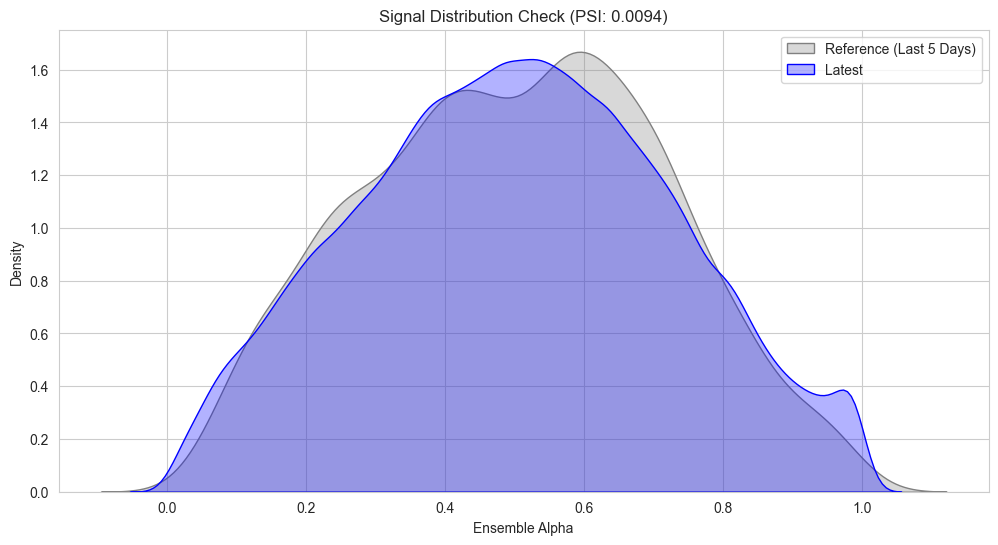

2026-03-23 11:11:41,544 - INFO - ✅ Distribution Stable. PSI: 0.0094


In [18]:
# --- 1. Signal Distribution & Drift (PSI) ---

def calculate_psi(expected, actual, buckets=10, buckettype='quantiles'):
    '''Calculate the PSI (Population Stability Index) for a single variable'''
    
    # Robustness: Filter NaNs and check for empty data
    expected = expected[~np.isnan(expected)]
    actual = actual[~np.isnan(actual)]
    if len(expected) == 0 or len(actual) == 0:
        return 0.0

    # Define breakpoints
    if buckettype == 'bins':
        breakpoints = np.linspace(np.min(expected), np.max(expected), buckets + 1)
    else:
        # Quantile bins
        breakpoints = np.percentile(expected, np.linspace(0, 100, buckets + 1))

    # Guard against out-of-range values (Fat Tails) in actual data
    breakpoints[0] = -np.inf
    breakpoints[-1] = np.inf
    # Handle degenerate distributions (constant values) by removing duplicate bins
    breakpoints = np.unique(breakpoints)

    # Calculate frequencies
    expected_counts, _ = np.histogram(expected, breakpoints)
    actual_counts, _ = np.histogram(actual, breakpoints)
    
    # Convert to probabilities (add epsilon to avoid division by zero)
    epsilon = 1e-4
    expected_percents = np.maximum(expected_counts / len(expected), epsilon)
    actual_percents = np.maximum(actual_counts / len(actual), epsilon)

    # Calculate PSI
    psi_values = (expected_percents - actual_percents) * np.log(expected_percents / actual_percents)
    psi_total = np.sum(psi_values)
    
    return psi_total

# Compute PSI
psi_val = calculate_psi(df_ref['ensemble_alpha'].values, df_latest['ensemble_alpha'].values, buckets=10, buckettype='quantiles')

# Visualization
plt.figure(figsize=(12, 6))
sns.kdeplot(df_ref['ensemble_alpha'], label='Reference (Last 5 Days)', fill=True, alpha=0.3, color='grey')
sns.kdeplot(df_latest['ensemble_alpha'], label='Latest', fill=True, alpha=0.3, color='blue')
plt.title(f"Signal Distribution Check (PSI: {psi_val:.4f})")
plt.xlabel("Ensemble Alpha")
plt.legend()
plt.show()

# Alerting
if psi_val > PSI_THRESHOLD:
    logger.error(f"🚨 HIGH DRIFT DETECTED: PSI {psi_val:.4f} > {PSI_THRESHOLD}")
else:
    logger.info(f"✅ Distribution Stable. PSI: {psi_val:.4f}")

In [19]:
# --- 2. Statistical Health Checks ---

stats = df_latest['ensemble_alpha'].describe()
std_dev = stats['std']
min_val = stats['min']
max_val = stats['max']
n_tickers = df_latest['ticker'].nunique()

print(f"{'Metric':<20} | {'Value':<15} | {'Status':<10}")
print("-" * 50)

# 1. Variance Check
status_var = "✅ OK" if std_dev > MIN_SIGNAL_STD else "❌ FAIL"
print(f"{'Std Dev':<20} | {std_dev:<15.5f} | {status_var}")

# 2. Bounds Check
status_bounds = "✅ OK" if (abs(min_val) < MAX_SIGNAL_ABS and abs(max_val) < MAX_SIGNAL_ABS) else "❌ FAIL"
print(f"{'Min/Max':<20} | {min_val:.2f}/{max_val:.2f}   | {status_bounds}")

# 3. Universe Check
status_univ = "✅ OK" if n_tickers >= MIN_TICKERS else "⚠️ LOW"
print(f"{'Ticker Count':<20} | {n_tickers:<15} | {status_univ}")

if std_dev <= MIN_SIGNAL_STD:
    logger.error("🚨 SIGNAL COLLAPSE: Standard deviation is near zero. Model may be outputting constant values.")

Metric               | Value           | Status    
--------------------------------------------------
Std Dev              | 0.22361         | ✅ OK
Min/Max              | 0.00/1.00   | ✅ OK
Ticker Count         | 441             | ✅ OK


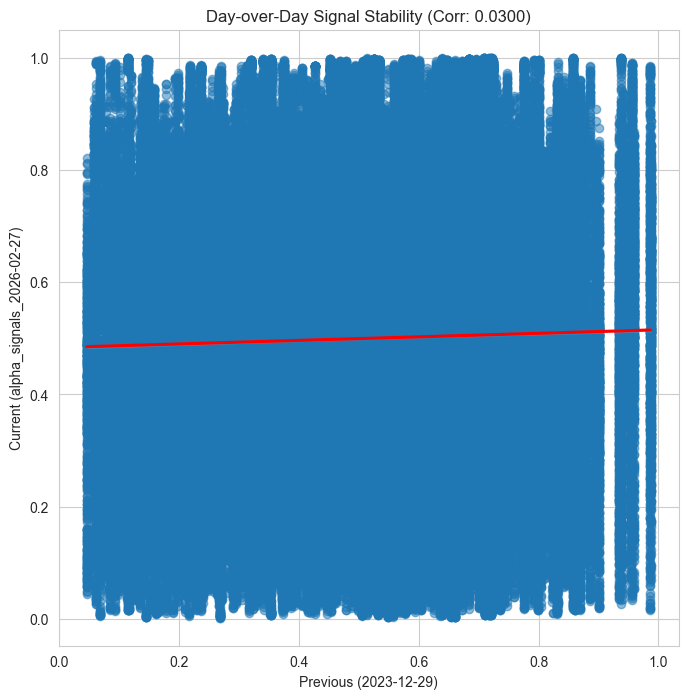

2026-03-23 11:12:06,549 - INFO - Day-over-Day Correlation: 0.0300
2026-03-23 11:12:06,549 - WARNING - ⚠️ Low stability: Signals changed significantly since yesterday.


In [20]:
# --- 3. Turnover / Stability Proxy ---
# Check correlation with the immediately preceding day (if available) to ensure we aren't flipping signs randomly (unless expected).

df_prev = pd.DataFrame()
prev_name = "Unknown"

if len(files) >= 2:
    prev_file = files[-2]
    df_prev = load_parquet(prev_file)
    df_prev['date'] = pd.to_datetime(df_prev['date'])
    prev_date = df_prev['date'].max()
    df_prev = df_prev[df_prev['date'] == prev_date]
    prev_name = str(prev_date.date())
else:
    # Fallback to cache
    cache_path = config.CACHE_DIR / 'ensemble_predictions.parquet'
    if cache_path.exists():
        df_cache = load_parquet(cache_path)
        df_cache['date'] = pd.to_datetime(df_cache['date'])
        # Find the max date less than current
        current_date = df_latest['date'].min()
        available_dates = df_cache[df_cache['date'] < current_date]['date'].unique()
        if len(available_dates) > 0:
            prev_date = sorted(available_dates)[-1]
            df_prev = df_cache[df_cache['date'] == prev_date]
            prev_name = str(prev_date.date())
            logger.info(f"Loaded previous day from cache: {prev_name}")

if not df_prev.empty:
    # Merge on ticker
    merged = pd.merge(df_latest, df_prev, on='ticker', suffixes=('_curr', '_prev'))
    
    if not merged.empty:
        corr = merged['ensemble_alpha_curr'].corr(merged['ensemble_alpha_prev'])
        
        plt.figure(figsize=(8, 8))
        sns.regplot(x='ensemble_alpha_prev', y='ensemble_alpha_curr', data=merged, scatter_kws={'alpha':0.5}, line_kws={'color':'red'})
        plt.title(f"Day-over-Day Signal Stability (Corr: {corr:.4f})")
        plt.xlabel(f"Previous ({prev_name})")
        plt.ylabel(f"Current ({latest_file.stem})")
        plt.show()
        
        logger.info(f"Day-over-Day Correlation: {corr:.4f}")
        if corr < 0.5:
            logger.warning("⚠️ Low stability: Signals changed significantly since yesterday.")
    else:
        logger.warning("No overlapping tickers found between last two predictions.")
else:
    logger.info("Not enough history for stability check (No previous files or cache).")

In [21]:
# --- 4. Final Executive Summary ---
# Generate a simple report dictionary or printout

report = {
    "date": latest_date,
    "psi": psi_val,
    "std_dev": std_dev,
    "ticker_count": n_tickers,
    "status": "PASS" if (psi_val < PSI_THRESHOLD and std_dev > MIN_SIGNAL_STD) else "REVIEW_REQUIRED"
}

print("\n" + "="*40)
print(f"  MONITORING STATUS: {report['status']}")
print("="*40)
print(f"  Date:       {report['date']}")
print(f"  PSI:        {report['psi']:.4f}")
print(f"  Signal Std: {report['std_dev']:.5f}")
print(f"  Tickers:    {report['ticker_count']}")
print("="*40)


  MONITORING STATUS: PASS
  Date:       2026-02-27
  PSI:        0.0094
  Signal Std: 0.22361
  Tickers:    441
